In [1]:
!pip install medmnist

In [2]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

from torchvision import transforms, models
from medmnist import PathMNIST

print("PyTorch:", torch.__version__)
print("CUDA disponível:", torch.cuda.is_available())

PyTorch: 2.11.0+cu128
CUDA disponível: True


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo usado:", device)

Dispositivo usado: cuda


In [4]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
train_set_224 = PathMNIST(
    split="train",
    size=28,
    transform=transform_train,
    download=True
)

val_set_224 = PathMNIST(
    split="val",
    size=28,
    transform=transform_val,
    download=True
)

print("Treino:", len(train_set_224))
print("Validação:", len(val_set_224))

100%|██████████| 206M/206M [01:05<00:00, 3.14MB/s]


Treino: 89996
Validação: 10004


In [6]:
train_subset = Subset(train_set_224, range(3000))
val_subset = Subset(val_set_224, range(800))

batch_size = 16

train_loader = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=batch_size,
    shuffle=False
)

print("Batches de treino:", len(train_loader))
print("Batches de validação:", len(val_loader))

Batches de treino: 188
Batches de validação: 50


In [7]:
imagens, labels = next(iter(train_loader))

print("Formato das imagens:", imagens.shape)
print("Formato dos labels:", labels.shape)
print("Primeiros labels:", labels[:10].squeeze())

Formato das imagens: torch.Size([16, 3, 224, 224])
Formato dos labels: torch.Size([16, 1])
Primeiros labels: tensor([4, 7, 2, 8, 8, 5, 6, 6, 6, 5])


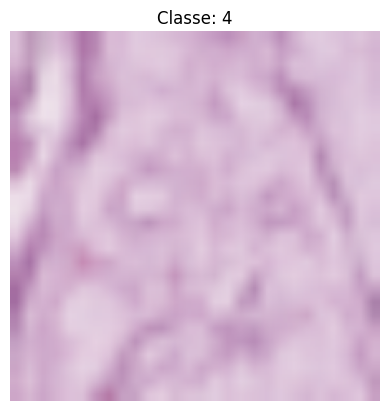

In [8]:
def mostrar_imagem_tensor(img_tensor, label):
    img = img_tensor.clone().permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(f"Classe: {label}")
    plt.axis("off")
    plt.show()


mostrar_imagem_tensor(imagens[0], labels[0].item())

In [9]:
class CNNPropria(nn.Module):
    def __init__(self, num_classes=9):
        super().__init__()

        self.features = nn.Sequential(
            # Bloco 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloco 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloco 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Dropout(0.3)
        )

        self.classificador = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classificador(x)
        return x

In [10]:
cnn_propria = CNNPropria(num_classes=9).to(device)

imagens_teste, labels_teste = next(iter(train_loader))
imagens_teste = imagens_teste.to(device)

saidas = cnn_propria(imagens_teste)

print(cnn_propria)
print("Formato da saída:", saidas.shape)

CNNPropria(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout(p=0.3, inplace=False)
  )
  (classificador): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=2

In [11]:
def treinar_uma_epoca(modelo, dataloader, criterio, otimizador, device):
    modelo.train()

    perda_total = 0
    acertos = 0
    total = 0

    for imagens, labels in dataloader:
        imagens = imagens.to(device)
        labels = labels.squeeze().long().to(device)

        otimizador.zero_grad()

        saidas = modelo(imagens)
        perda = criterio(saidas, labels)

        perda.backward()
        otimizador.step()

        perda_total += perda.item() * imagens.size(0)

        previsoes = torch.argmax(saidas, dim=1)
        acertos += (previsoes == labels).sum().item()
        total += labels.size(0)

    perda_media = perda_total / total
    acuracia = acertos / total

    return perda_media, acuracia


def avaliar(modelo, dataloader, criterio, device):
    modelo.eval()

    perda_total = 0
    acertos = 0
    total = 0

    with torch.no_grad():
        for imagens, labels in dataloader:
            imagens = imagens.to(device)
            labels = labels.squeeze().long().to(device)

            saidas = modelo(imagens)
            perda = criterio(saidas, labels)

            perda_total += perda.item() * imagens.size(0)

            previsoes = torch.argmax(saidas, dim=1)
            acertos += (previsoes == labels).sum().item()
            total += labels.size(0)

    perda_media = perda_total / total
    acuracia = acertos / total

    return perda_media, acuracia

In [12]:
cnn_propria = CNNPropria(num_classes=9).to(device)

criterio = nn.CrossEntropyLoss()

otimizador = optim.Adam(
    cnn_propria.parameters(),
    lr=0.001
)

print("CNN própria criada e pronta para treinamento.")

CNN própria criada e pronta para treinamento.


In [13]:
historico_cnn = {
    "loss_train": [],
    "acc_train": [],
    "loss_val": [],
    "acc_val": []
}

epocas = 5

inicio = time.time()

for epoca in range(1, epocas + 1):
    loss_train, acc_train = treinar_uma_epoca(
        cnn_propria,
        train_loader,
        criterio,
        otimizador,
        device
    )

    loss_val, acc_val = avaliar(
        cnn_propria,
        val_loader,
        criterio,
        device
    )

    historico_cnn["loss_train"].append(loss_train)
    historico_cnn["acc_train"].append(acc_train)
    historico_cnn["loss_val"].append(loss_val)
    historico_cnn["acc_val"].append(acc_val)

    print(
        f"Época {epoca:02d} | "
        f"Loss treino: {loss_train:.4f} | Acc treino: {acc_train:.4f} | "
        f"Loss val: {loss_val:.4f} | Acc val: {acc_val:.4f}"
    )

fim = time.time()

tempo_total = fim - inicio
print(f"Tempo total de treinamento: {tempo_total:.2f} segundos")

Época 01 | Loss treino: 3.6231 | Acc treino: 0.2597 | Loss val: 1.7636 | Acc val: 0.4138
Época 02 | Loss treino: 1.8489 | Acc treino: 0.3307 | Loss val: 1.6637 | Acc val: 0.4150
Época 03 | Loss treino: 1.7904 | Acc treino: 0.3490 | Loss val: 1.7673 | Acc val: 0.3500
Época 04 | Loss treino: 1.7806 | Acc treino: 0.3453 | Loss val: 1.7777 | Acc val: 0.4350
Época 05 | Loss treino: 1.6458 | Acc treino: 0.3897 | Loss val: 1.6944 | Acc val: 0.4313
Tempo total de treinamento: 68.54 segundos


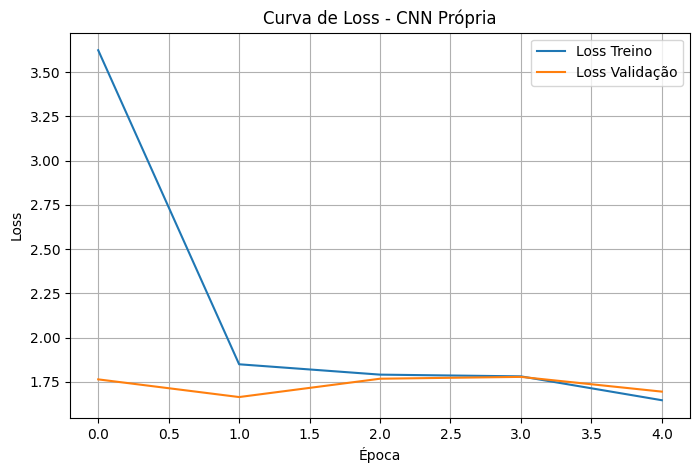

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(historico_cnn["loss_train"], label="Loss Treino")
plt.plot(historico_cnn["loss_val"], label="Loss Validação")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de Loss - CNN Própria")
plt.legend()
plt.grid(True)
plt.show()

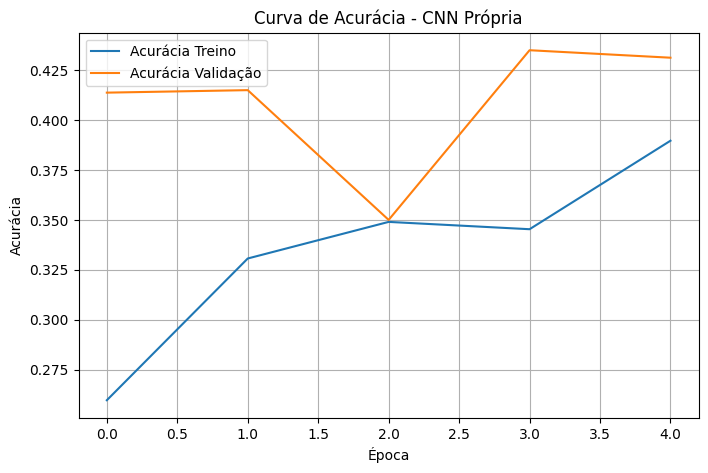

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(historico_cnn["acc_train"], label="Acurácia Treino")
plt.plot(historico_cnn["acc_val"], label="Acurácia Validação")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Curva de Acurácia - CNN Própria")
plt.legend()
plt.grid(True)
plt.show()

## CNN própria

Foi implementada uma CNN autoral com três blocos convolucionais, utilizando convolução 2D, Batch Normalization, ReLU, MaxPooling e Dropout. A entrada utilizada foi o PathMNIST na resolução 224x224, conforme especificado no enunciado.

Devido às limitações computacionais do ambiente local, o treinamento foi realizado inicialmente com um subconjunto de 3000 imagens de treino e 800 imagens de validação, usando batch size 16 e 5 épocas. O objetivo desta etapa foi validar a arquitetura e demonstrar o funcionamento de uma CNN própria antes de avançar para modelos pré-treinados.

## MobileNetV2 pré-treinada — Feature Extraction

Nesta etapa foi utilizada a MobileNetV2 pré-treinada no ImageNet. Inicialmente, o backbone foi congelado e apenas a camada final de classificação foi substituída para adaptar o modelo às 9 classes do PathMNIST. Essa abordagem é chamada de Feature Extraction.

In [16]:
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

modelo_mobilenet = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

# Congela o backbone
for param in modelo_mobilenet.features.parameters():
    param.requires_grad = False

# Troca a camada final para 9 classes
modelo_mobilenet.classifier[1] = nn.Linear(
    modelo_mobilenet.classifier[1].in_features,
    9
)

modelo_mobilenet = modelo_mobilenet.to(device)

criterio = nn.CrossEntropyLoss()

otimizador_mobilenet = optim.AdamW(
    modelo_mobilenet.classifier.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print(modelo_mobilenet)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 223MB/s]

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [17]:
historico_mobilenet = {
    "loss_train": [],
    "acc_train": [],
    "loss_val": [],
    "acc_val": []
}

epocas = 5

inicio = time.time()

for epoca in range(1, epocas + 1):
    loss_train, acc_train = treinar_uma_epoca(
        modelo_mobilenet,
        train_loader,
        criterio,
        otimizador_mobilenet,
        device
    )

    loss_val, acc_val = avaliar(
        modelo_mobilenet,
        val_loader,
        criterio,
        device
    )

    historico_mobilenet["loss_train"].append(loss_train)
    historico_mobilenet["acc_train"].append(acc_train)
    historico_mobilenet["loss_val"].append(loss_val)
    historico_mobilenet["acc_val"].append(acc_val)

    print(
        f"Época {epoca:02d} | "
        f"Loss treino: {loss_train:.4f} | Acc treino: {acc_train:.4f} | "
        f"Loss val: {loss_val:.4f} | Acc val: {acc_val:.4f}"
    )

fim = time.time()

tempo_mobilenet = fim - inicio
print(f"Tempo total MobileNetV2: {tempo_mobilenet:.2f} segundos")

Época 01 | Loss treino: 1.0587 | Acc treino: 0.6473 | Loss val: 0.5452 | Acc val: 0.8400
Época 02 | Loss treino: 0.6465 | Acc treino: 0.7810 | Loss val: 0.4788 | Acc val: 0.8462
Época 03 | Loss treino: 0.5714 | Acc treino: 0.7977 | Loss val: 0.4514 | Acc val: 0.8462
Época 04 | Loss treino: 0.5412 | Acc treino: 0.8167 | Loss val: 0.4255 | Acc val: 0.8538
Época 05 | Loss treino: 0.5075 | Acc treino: 0.8110 | Loss val: 0.3604 | Acc val: 0.8800
Tempo total MobileNetV2: 47.41 segundos


### Resultado da MobileNetV2

A MobileNetV2 pré-treinada apresentou desempenho significativamente superior à CNN própria. Com o backbone congelado e apenas a camada final treinável, o modelo atingiu aproximadamente 88% de acurácia na validação após 5 épocas.

Esse resultado mostra a vantagem do Transfer Learning, pois o modelo já possuía filtros visuais aprendidos em um grande conjunto de imagens, permitindo melhor extração de características mesmo com poucas épocas de treinamento.

## ResNet18 pré-treinada — Feature Extraction

Nesta etapa foi utilizada a ResNet18 pré-treinada no ImageNet. Assim como na MobileNetV2, o backbone foi congelado e apenas a camada final foi substituída para classificar as 9 classes do PathMNIST.

In [18]:
from torchvision.models import resnet18, ResNet18_Weights

modelo_resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Congela todas as camadas
for param in modelo_resnet.parameters():
    param.requires_grad = False

# Substitui a camada final
modelo_resnet.fc = nn.Linear(modelo_resnet.fc.in_features, 9)

modelo_resnet = modelo_resnet.to(device)

criterio = nn.CrossEntropyLoss()

otimizador_resnet = optim.AdamW(
    modelo_resnet.fc.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print(modelo_resnet)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 210MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [19]:
historico_resnet = {
    "loss_train": [],
    "acc_train": [],
    "loss_val": [],
    "acc_val": []
}

epocas = 5

inicio = time.time()

for epoca in range(1, epocas + 1):
    loss_train, acc_train = treinar_uma_epoca(
        modelo_resnet,
        train_loader,
        criterio,
        otimizador_resnet,
        device
    )

    loss_val, acc_val = avaliar(
        modelo_resnet,
        val_loader,
        criterio,
        device
    )

    historico_resnet["loss_train"].append(loss_train)
    historico_resnet["acc_train"].append(acc_train)
    historico_resnet["loss_val"].append(loss_val)
    historico_resnet["acc_val"].append(acc_val)

    print(
        f"Época {epoca:02d} | "
        f"Loss treino: {loss_train:.4f} | Acc treino: {acc_train:.4f} | "
        f"Loss val: {loss_val:.4f} | Acc val: {acc_val:.4f}"
    )

fim = time.time()

tempo_resnet = fim - inicio
print(f"Tempo total ResNet18: {tempo_resnet:.2f} segundos")

Época 01 | Loss treino: 1.2567 | Acc treino: 0.5977 | Loss val: 0.7276 | Acc val: 0.7925
Época 02 | Loss treino: 0.7427 | Acc treino: 0.7613 | Loss val: 0.5821 | Acc val: 0.8200
Época 03 | Loss treino: 0.6221 | Acc treino: 0.7940 | Loss val: 0.5311 | Acc val: 0.8150
Época 04 | Loss treino: 0.5781 | Acc treino: 0.8130 | Loss val: 0.5354 | Acc val: 0.8125
Época 05 | Loss treino: 0.5291 | Acc treino: 0.8243 | Loss val: 0.4959 | Acc val: 0.8337
Tempo total ResNet18: 44.72 segundos


## EfficientNet-B0 pré-treinada — Feature Extraction

Nesta etapa foi utilizada a EfficientNet-B0 pré-treinada no ImageNet. O backbone foi congelado e a camada final foi adaptada para as 9 classes do PathMNIST. A EfficientNet é uma arquitetura moderna que busca equilibrar profundidade, largura e resolução de forma eficiente.

In [20]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

modelo_efficientnet = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# Congela todas as camadas
for param in modelo_efficientnet.parameters():
    param.requires_grad = False

# Substitui a camada final
modelo_efficientnet.classifier[1] = nn.Linear(
    modelo_efficientnet.classifier[1].in_features,
    9
)

modelo_efficientnet = modelo_efficientnet.to(device)

criterio = nn.CrossEntropyLoss()

otimizador_efficientnet = optim.AdamW(
    modelo_efficientnet.classifier.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print(modelo_efficientnet)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 147MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [21]:
historico_efficientnet = {
    "loss_train": [],
    "acc_train": [],
    "loss_val": [],
    "acc_val": []
}

epocas = 5

inicio = time.time()

for epoca in range(1, epocas + 1):
    loss_train, acc_train = treinar_uma_epoca(
        modelo_efficientnet,
        train_loader,
        criterio,
        otimizador_efficientnet,
        device
    )

    loss_val, acc_val = avaliar(
        modelo_efficientnet,
        val_loader,
        criterio,
        device
    )

    historico_efficientnet["loss_train"].append(loss_train)
    historico_efficientnet["acc_train"].append(acc_train)
    historico_efficientnet["loss_val"].append(loss_val)
    historico_efficientnet["acc_val"].append(acc_val)

    print(
        f"Época {epoca:02d} | "
        f"Loss treino: {loss_train:.4f} | Acc treino: {acc_train:.4f} | "
        f"Loss val: {loss_val:.4f} | Acc val: {acc_val:.4f}"
    )

fim = time.time()

tempo_efficientnet = fim - inicio
print(f"Tempo total EfficientNet-B0: {tempo_efficientnet:.2f} segundos")

Época 01 | Loss treino: 1.1462 | Acc treino: 0.6637 | Loss val: 1.0063 | Acc val: 0.7887
Época 02 | Loss treino: 0.6869 | Acc treino: 0.7847 | Loss val: 0.5782 | Acc val: 0.8375
Época 03 | Loss treino: 0.6269 | Acc treino: 0.7950 | Loss val: 1.0591 | Acc val: 0.8400
Época 04 | Loss treino: 0.5545 | Acc treino: 0.8273 | Loss val: 1.0761 | Acc val: 0.8400
Época 05 | Loss treino: 0.5248 | Acc treino: 0.8233 | Loss val: 0.4631 | Acc val: 0.8550
Tempo total EfficientNet-B0: 50.72 segundos


## Comparação parcial dos modelos

A tabela abaixo resume os resultados obtidos até o momento na Etapa 3. Foram comparados uma CNN própria treinada do zero e três modelos pré-treinados utilizando Feature Extraction: MobileNetV2, ResNet18 e EfficientNet-B0.

In [22]:
import pandas as pd

resultados_modelos = pd.DataFrame({
    "Modelo": [
        "CNN própria",
        "MobileNetV2",
        "ResNet18",
        "EfficientNet-B0"
    ],
    "Estratégia": [
        "Treino do zero",
        "Feature Extraction",
        "Feature Extraction",
        "Feature Extraction"
    ],
    "Otimizador": [
        "Adam",
        "AdamW",
        "AdamW",
        "AdamW"
    ],
    "Learning Rate": [
        0.001,
        0.001,
        0.001,
        0.001
    ],
    "Acurácia Validação": [
        historico_cnn["acc_val"][-1],
        historico_mobilenet["acc_val"][-1],
        historico_resnet["acc_val"][-1],
        historico_efficientnet["acc_val"][-1]
    ],
    "Loss Validação": [
        historico_cnn["loss_val"][-1],
        historico_mobilenet["loss_val"][-1],
        historico_resnet["loss_val"][-1],
        historico_efficientnet["loss_val"][-1]
    ],
    "Tempo de Treino (s)": [
        tempo_total,
        tempo_mobilenet,
        tempo_resnet,
        tempo_efficientnet
    ]
})

resultados_modelos

,Modelo,Estratégia,Otimizador,Learning Rate,Acurácia Validação,Loss Validação,Tempo de Treino (s)
0,CNN própria,Treino do zero,Adam,0.001,0.43125,1.694368,68.539463
1,MobileNetV2,Feature Extraction,AdamW,0.001,0.88000,0.360381,47.414257
2,ResNet18,Feature Extraction,AdamW,0.001,0.83375,0.495911,44.718123
3,EfficientNet-B0,Feature Extraction,AdamW,0.001,0.85500,0.463079,50.723386


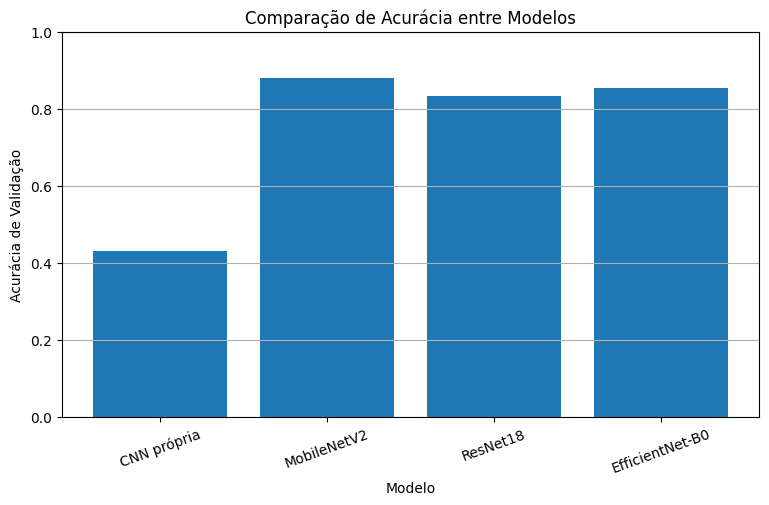

In [23]:
plt.figure(figsize=(9, 5))
plt.bar(
    resultados_modelos["Modelo"],
    resultados_modelos["Acurácia Validação"]
)

plt.xlabel("Modelo")
plt.ylabel("Acurácia de Validação")
plt.title("Comparação de Acurácia entre Modelos")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

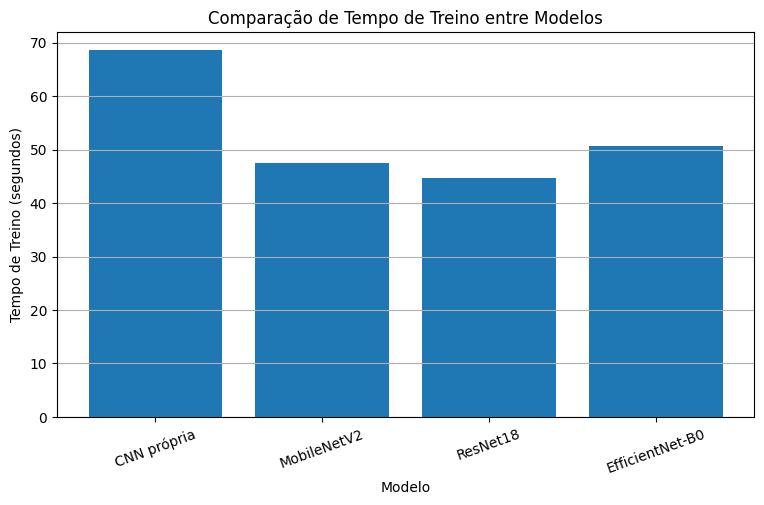

In [24]:
plt.figure(figsize=(9, 5))
plt.bar(
    resultados_modelos["Modelo"],
    resultados_modelos["Tempo de Treino (s)"]
)

plt.xlabel("Modelo")
plt.ylabel("Tempo de Treino (segundos)")
plt.title("Comparação de Tempo de Treino entre Modelos")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

### Discussão parcial

Os resultados mostram que os modelos pré-treinados superaram significativamente a CNN própria. A MobileNetV2 obteve o melhor desempenho de validação entre os modelos avaliados até o momento, atingindo aproximadamente 88% de acurácia.

Esse resultado indica que o uso de Transfer Learning foi vantajoso para o problema, pois os modelos pré-treinados já possuem filtros visuais úteis aprendidos em grandes bases de imagens. Mesmo com o backbone congelado, os classificadores finais conseguiram adaptar essas representações para as 9 classes do PathMNIST.

A CNN própria apresentou desempenho inferior, o que era esperado, pois foi treinada do zero com um subconjunto reduzido de dados e poucas épocas. Ainda assim, ela cumpre o papel de arquitetura autoral e serve como baseline para comparação.

## Swin Transformer pré-treinado — Feature Extraction

Nesta etapa foi utilizado o Swin Transformer Tiny pré-treinado no ImageNet. Diferente das CNNs, o Swin utiliza mecanismos de atenção em janelas locais, permitindo capturar relações espaciais de forma diferente das convoluções tradicionais.

Assim como nos modelos anteriores, foi aplicada a estratégia de Feature Extraction: o backbone foi congelado e apenas a camada final foi ajustada para as 9 classes do PathMNIST.

In [25]:
from torchvision.models import swin_t, Swin_T_Weights

modelo_swin = swin_t(weights=Swin_T_Weights.IMAGENET1K_V1)

# Congela todas as camadas do backbone
for param in modelo_swin.parameters():
    param.requires_grad = False

# Substitui a cabeça de classificação para 9 classes
modelo_swin.head = nn.Linear(
    modelo_swin.head.in_features,
    9
)

modelo_swin = modelo_swin.to(device)

criterio = nn.CrossEntropyLoss()

otimizador_swin = optim.AdamW(
    modelo_swin.head.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print(modelo_swin)

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 193MB/s]


SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (proj): Linear(in_features=96, out_features=96, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=384, out_features=96, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock(
       

In [26]:
historico_swin = {
    "loss_train": [],
    "acc_train": [],
    "loss_val": [],
    "acc_val": []
}

epocas = 5

inicio = time.time()

for epoca in range(1, epocas + 1):
    loss_train, acc_train = treinar_uma_epoca(
        modelo_swin,
        train_loader,
        criterio,
        otimizador_swin,
        device
    )

    loss_val, acc_val = avaliar(
        modelo_swin,
        val_loader,
        criterio,
        device
    )

    historico_swin["loss_train"].append(loss_train)
    historico_swin["acc_train"].append(acc_train)
    historico_swin["loss_val"].append(loss_val)
    historico_swin["acc_val"].append(acc_val)

    print(
        f"Época {epoca:02d} | "
        f"Loss treino: {loss_train:.4f} | Acc treino: {acc_train:.4f} | "
        f"Loss val: {loss_val:.4f} | Acc val: {acc_val:.4f}"
    )

fim = time.time()

tempo_swin = fim - inicio
print(f"Tempo total Swin-T: {tempo_swin:.2f} segundos")

Época 01 | Loss treino: 1.1621 | Acc treino: 0.6433 | Loss val: 0.7148 | Acc val: 0.8075
Época 02 | Loss treino: 0.6959 | Acc treino: 0.7837 | Loss val: 0.5663 | Acc val: 0.8300
Época 03 | Loss treino: 0.5996 | Acc treino: 0.8060 | Loss val: 0.5152 | Acc val: 0.8425
Época 04 | Loss treino: 0.5491 | Acc treino: 0.8237 | Loss val: 0.4672 | Acc val: 0.8488
Época 05 | Loss treino: 0.5116 | Acc treino: 0.8330 | Loss val: 0.4488 | Acc val: 0.8588
Tempo total Swin-T: 111.89 segundos


In [27]:
resultados_modelos = pd.DataFrame({
    "Modelo": [
        "CNN própria",
        "MobileNetV2",
        "ResNet18",
        "EfficientNet-B0",
        "Swin-T"
    ],
    "Estratégia": [
        "Treino do zero",
        "Feature Extraction",
        "Feature Extraction",
        "Feature Extraction",
        "Feature Extraction"
    ],
    "Otimizador": [
        "Adam",
        "AdamW",
        "AdamW",
        "AdamW",
        "AdamW"
    ],
    "Learning Rate": [
        0.001,
        0.001,
        0.001,
        0.001,
        0.001
    ],
    "Acurácia Validação": [
        historico_cnn["acc_val"][-1],
        historico_mobilenet["acc_val"][-1],
        historico_resnet["acc_val"][-1],
        historico_efficientnet["acc_val"][-1],
        historico_swin["acc_val"][-1]
    ],
    "Loss Validação": [
        historico_cnn["loss_val"][-1],
        historico_mobilenet["loss_val"][-1],
        historico_resnet["loss_val"][-1],
        historico_efficientnet["loss_val"][-1],
        historico_swin["loss_val"][-1]
    ],
    "Tempo de Treino (s)": [
        tempo_total,
        tempo_mobilenet,
        tempo_resnet,
        tempo_efficientnet,
        tempo_swin
    ]
})

resultados_modelos

,Modelo,Estratégia,Otimizador,Learning Rate,Acurácia Validação,Loss Validação,Tempo de Treino (s)
0,CNN própria,Treino do zero,Adam,0.001,0.43125,1.694368,68.539463
1,MobileNetV2,Feature Extraction,AdamW,0.001,0.88000,0.360381,47.414257
2,ResNet18,Feature Extraction,AdamW,0.001,0.83375,0.495911,44.718123
3,EfficientNet-B0,Feature Extraction,AdamW,0.001,0.85500,0.463079,50.723386
4,Swin-T,Feature Extraction,AdamW,0.001,0.85875,0.448823,111.889561


### Discussão com Swin Transformer

Com a inclusão do Swin-T, foi possível comparar modelos convolucionais com uma arquitetura baseada em atenção. O Swin-T obteve desempenho competitivo, atingindo aproximadamente 85,9% de acurácia na validação, ficando próximo da EfficientNet-B0 e abaixo da MobileNetV2.

Apesar do bom desempenho, o Swin-T apresentou maior tempo de treinamento em comparação com as CNNs pré-treinadas mais leves. Isso indica que, para este experimento, a MobileNetV2 apresentou o melhor custo-benefício entre acurácia e tempo computacional.

## MobileNetV2 — Fine-tuning parcial

Como a MobileNetV2 apresentou o melhor desempenho na etapa de Feature Extraction, foi realizado um fine-tuning parcial. Nesta abordagem, parte das camadas finais do backbone foi descongelada, permitindo que o modelo ajustasse representações mais específicas para o PathMNIST.

Foi utilizada uma taxa de aprendizado menor para evitar grandes alterações nos pesos pré-treinados.

In [28]:
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

modelo_mobilenet_ft = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

# Primeiro congela tudo
for param in modelo_mobilenet_ft.parameters():
    param.requires_grad = False

# Substitui a camada final para 9 classes
modelo_mobilenet_ft.classifier[1] = nn.Linear(
    modelo_mobilenet_ft.classifier[1].in_features,
    9
)

# Descongela os últimos blocos do backbone para fine-tuning parcial
for param in modelo_mobilenet_ft.features[-3:].parameters():
    param.requires_grad = True

# Também deixa o classificador treinável
for param in modelo_mobilenet_ft.classifier.parameters():
    param.requires_grad = True

modelo_mobilenet_ft = modelo_mobilenet_ft.to(device)

criterio = nn.CrossEntropyLoss()

otimizador_mobilenet_ft = optim.AdamW(
    filter(lambda p: p.requires_grad, modelo_mobilenet_ft.parameters()),
    lr=0.0001,
    weight_decay=1e-4
)

print("MobileNetV2 preparada para fine-tuning parcial.")

MobileNetV2 preparada para fine-tuning parcial.


In [29]:
historico_mobilenet_ft = {
    "loss_train": [],
    "acc_train": [],
    "loss_val": [],
    "acc_val": []
}

epocas = 5

inicio = time.time()

for epoca in range(1, epocas + 1):
    loss_train, acc_train = treinar_uma_epoca(
        modelo_mobilenet_ft,
        train_loader,
        criterio,
        otimizador_mobilenet_ft,
        device
    )

    loss_val, acc_val = avaliar(
        modelo_mobilenet_ft,
        val_loader,
        criterio,
        device
    )

    historico_mobilenet_ft["loss_train"].append(loss_train)
    historico_mobilenet_ft["acc_train"].append(acc_train)
    historico_mobilenet_ft["loss_val"].append(loss_val)
    historico_mobilenet_ft["acc_val"].append(acc_val)

    print(
        f"Época {epoca:02d} | "
        f"Loss treino: {loss_train:.4f} | Acc treino: {acc_train:.4f} | "
        f"Loss val: {loss_val:.4f} | Acc val: {acc_val:.4f}"
    )

fim = time.time()

tempo_mobilenet_ft = fim - inicio
print(f"Tempo total MobileNetV2 Fine-tuning: {tempo_mobilenet_ft:.2f} segundos")

Época 01 | Loss treino: 0.8485 | Acc treino: 0.7313 | Loss val: 0.3546 | Acc val: 0.8950
Época 02 | Loss treino: 0.4200 | Acc treino: 0.8603 | Loss val: 0.2881 | Acc val: 0.9100
Época 03 | Loss treino: 0.3538 | Acc treino: 0.8773 | Loss val: 0.2692 | Acc val: 0.9163
Época 04 | Loss treino: 0.2742 | Acc treino: 0.9110 | Loss val: 0.2667 | Acc val: 0.9050
Época 05 | Loss treino: 0.2224 | Acc treino: 0.9253 | Loss val: 0.2799 | Acc val: 0.8988
Tempo total MobileNetV2 Fine-tuning: 48.60 segundos


In [30]:
resultados_modelos = pd.DataFrame({
    "Modelo": [
        "CNN própria",
        "MobileNetV2",
        "ResNet18",
        "EfficientNet-B0",
        "Swin-T",
        "MobileNetV2 Fine-tuning"
    ],
    "Estratégia": [
        "Treino do zero",
        "Feature Extraction",
        "Feature Extraction",
        "Feature Extraction",
        "Feature Extraction",
        "Fine-tuning parcial"
    ],
    "Otimizador": [
        "Adam",
        "AdamW",
        "AdamW",
        "AdamW",
        "AdamW",
        "AdamW"
    ],
    "Learning Rate": [
        0.001,
        0.001,
        0.001,
        0.001,
        0.001,
        0.0001
    ],
    "Acurácia Validação Final": [
        historico_cnn["acc_val"][-1],
        historico_mobilenet["acc_val"][-1],
        historico_resnet["acc_val"][-1],
        historico_efficientnet["acc_val"][-1],
        historico_swin["acc_val"][-1],
        historico_mobilenet_ft["acc_val"][-1]
    ],
    "Melhor Acurácia Validação": [
        max(historico_cnn["acc_val"]),
        max(historico_mobilenet["acc_val"]),
        max(historico_resnet["acc_val"]),
        max(historico_efficientnet["acc_val"]),
        max(historico_swin["acc_val"]),
        max(historico_mobilenet_ft["acc_val"])
    ],
    "Loss Validação Final": [
        historico_cnn["loss_val"][-1],
        historico_mobilenet["loss_val"][-1],
        historico_resnet["loss_val"][-1],
        historico_efficientnet["loss_val"][-1],
        historico_swin["loss_val"][-1],
        historico_mobilenet_ft["loss_val"][-1]
    ],
    "Tempo de Treino (s)": [
        tempo_total,
        tempo_mobilenet,
        tempo_resnet,
        tempo_efficientnet,
        tempo_swin,
        tempo_mobilenet_ft
    ]
})

resultados_modelos

,Modelo,Estratégia,Otimizador,Learning Rate,Acurácia Validação Final,Melhor Acurácia Validação,Loss Validação Final,Tempo de Treino (s)
0,CNN própria,Treino do zero,Adam,0.0010,0.43125,0.43500,1.694368,68.539463
1,MobileNetV2,Feature Extraction,AdamW,0.0010,0.88000,0.88000,0.360381,47.414257
2,ResNet18,Feature Extraction,AdamW,0.0010,0.83375,0.83375,0.495911,44.718123
3,EfficientNet-B0,Feature Extraction,AdamW,0.0010,0.85500,0.85500,0.463079,50.723386
4,Swin-T,Feature Extraction,AdamW,0.0010,0.85875,0.85875,0.448823,111.889561
5,MobileNetV2 Fine-tuning,Fine-tuning parcial,AdamW,0.0001,0.89875,0.91625,0.279896,48.604501


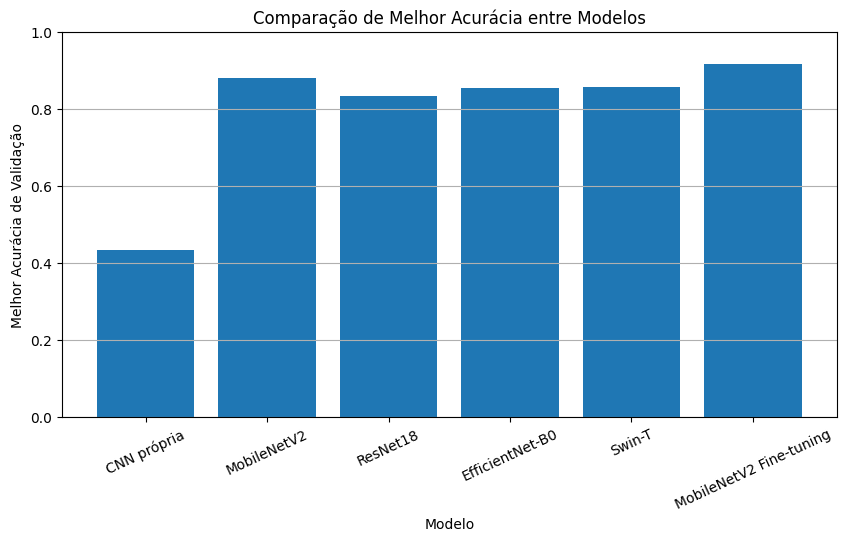

In [31]:
plt.figure(figsize=(10, 5))
plt.bar(
    resultados_modelos["Modelo"],
    resultados_modelos["Melhor Acurácia Validação"]
)

plt.xlabel("Modelo")
plt.ylabel("Melhor Acurácia de Validação")
plt.title("Comparação de Melhor Acurácia entre Modelos")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.grid(axis="y")
plt.show()

### Resultado do fine-tuning

O fine-tuning parcial da MobileNetV2 melhorou o desempenho em relação à estratégia de Feature Extraction. A acurácia final de validação foi de aproximadamente 89,9%, com pico de 91,6% na terceira época.

Esse resultado indica que descongelar parte das camadas finais permitiu ao modelo adaptar melhor suas representações ao domínio histopatológico do PathMNIST. Ainda assim, o desempenho oscilou nas épocas finais, o que sugere que técnicas como early stopping poderiam ser úteis para selecionar automaticamente o melhor checkpoint.